# New Project Testbench


Project Sturcture
- Reproduce Lia's work -> code at...
- Structurize e.g.
  - query
  - reformatting
  - saving
  - merging
  - expand

## Lia's work

### open questions
- is the way we get to the radius right?
    - e.g. should in addition the distance be taken into account?
    - starcat vs hpic radius, where does the difference come from?
    - should we stack the catalogs first before determining the radius?

### imports

In [1]:
from utils.io import load, stringtoobject, save
from utils.fcts_cat_merge import get_mask_cat2_in_cat1, nearest_neighbor_distances_units
from astropy.io.ascii import read
from utils.io import Path
from astropy.table import vstack, MaskedColumn
import numpy as np
from provider.utils import nullvalues

### load catalogs

In [2]:
# get HPIC
hpic = read(Path().additional_data+"/HPICv1.0/full_HPIC.txt",delimiter = "|")
# downloaded from https://exoplanetarchive.ipac.caltech.edu/docs/MissionStellar.html

In [10]:
print(hpic)
print(hpic.colnames)

         star_name                ra     ... sy_planets_flag hostname
---------------------------- ----------- ... --------------- --------
               TIC 459832522  213.915338 ...               0     null
               TIC 245873777   68.980213 ...               1  alf Tau
               TIC 272314138  187.791407 ...               0     null
               TIC 322899250  101.286998 ...               0     null
               TIC 368326352   79.172437 ...               0     null
               TIC 471011144  219.903981 ...               0     null
               TIC 280310048  114.825217 ...               0     null
               TIC 471011145  219.910043 ...               0     null
               TIC 157587146  279.234764 ...               0     null
               TIC 423088367  116.328966 ...               1 HD 62509
                         ...         ... ...             ...      ...
GAIA DR3 6742328107524142976 289.8782682 ...               0     null
GAIA DR3 67455736596

In [113]:
print(hpic["star_name","known_binary_fl"])

         star_name           known_binary_fl
---------------------------- ---------------
               TIC 459832522               1
               TIC 245873777               1
               TIC 272314138               1
               TIC 322899250               1
               TIC 368326352               1
               TIC 471011144               1
               TIC 280310048               1
               TIC 471011145               1
               TIC 157587146               1
               TIC 423088367               1
                         ...             ...
GAIA DR3 6742328107524142976               1
GAIA DR3 6745573659695679616               1
GAIA DR3 6792808541781612800               0
GAIA DR3 6823750688771587840               0
GAIA DR3 6827751124390424320               0
GAIA DR3 6832480291404495360               0
GAIA DR3 6833291426043854976               0
GAIA DR3 6896057214818851712               1
GAIA DR3 6910053108781758976               0
GAIA DR3 6

In [3]:
# get starcat50
[starcat5] = load(["catalogs/StarCat5"])

In [4]:
print(StarCat5_50pc.colnames)

['main_id', 'coo_ra', 'coo_dec', 'sptype_string', 'plx_value', 'dist_st_value', 'coo_gal_l', 'coo_gal_b', 'teff_st_value', 'teff_ref', 'mass_st_value', 'mass_ref', 'radius_st_value', 'radius_ref', 'binary_flag', 'binary_ref', 'mag_i_value', 'mag_j_value', 'class_lum', 'class_temp', 'parent_main_id', 'sep_ang_value', 'unresolved_binaries', 'ms_temp_class', 'ms_lum_class', 'mass_flag', 'higher_order_multiples', 'single_parent', 'trivial_binaries', 'sep_flag', 'sep_phys_value', 'requirement_flag', 'suitable_companions', 'stableHZ', 'ecliptic_pm45deg']


### compute matching radius

In [4]:
radius = nearest_neighbor_distances_units(starcat5["coo_ra"],starcat5["coo_dec"])
#strange error message, something about units but I did give right unit as requested in docstring


In [6]:
print(radius)

[1.36948670e+02 3.48331422e+03 3.62958072e+03 ... 0.00000000e+00
 1.49948267e+00 1.80393132e+03]


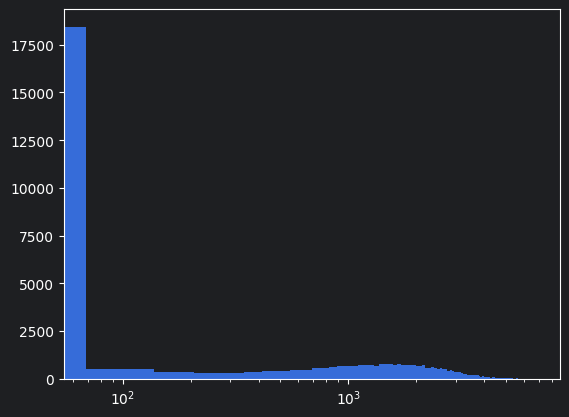

In [5]:
import matplotlib.pyplot as plt
plt.figure()
xs = [x for x in range(len(radius))]
plt.hist(radius,bins = 100)
plt.xscale('log')
plt.show()
#so did she use a single radius for all? I would have thought the farther away objects need a different one than the closer in ones
# like a star with 1pc separation is close in 1as but farther out way fewer
# 1pc separation at 50pc are?
# I can discuss that with her later, let's just take what this gives me
# most objects are very close by but a few have > 50 (as?) to their next neighbor

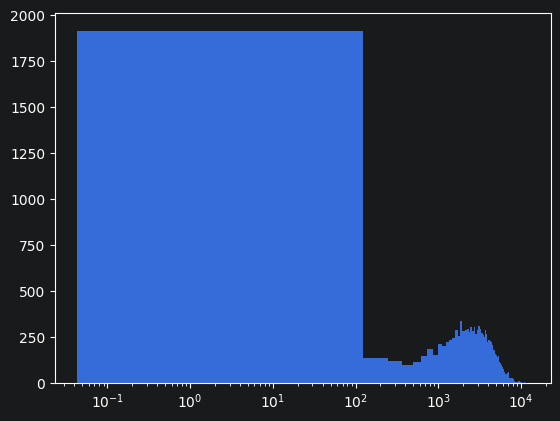

In [13]:
# test if different for both catalog combined
radius_hpic = nearest_neighbor_distances_units(hpic["ra"],hpic["dec"])
import matplotlib.pyplot as plt
plt.figure()
xs = [x for x in range(len(radius_hpic))]
plt.hist(radius_hpic,bins = 100)
plt.xscale('log')
plt.show()
# -> is more like slightly over 100

### mask catalog

I want to get hipc info and for stars not having it available get starcat info.
 so I am going to mask away all stars in starcat that have hipc info.
 then stack hpic together with the remaining stars from starcat.
 this means for the match function that cat 1 is hpic and cat 2 starcat.

In [5]:
# what does it mean for the radius, do I just take the rearest neighbor thing from starcat5 or do I need to reduce it?
# wait, the radius is supposed to be a float?

# match with starcat
mask_cat2_in_cat1 = get_mask_cat2_in_cat1(name_cat1 = hpic["simbad_name"],
                                          ra_cat1 = hpic["ra"],
                                          dec_cat1 = hpic["dec"],
                                          name_cat2 = starcat5["main_id"],
                                          ra_cat2 = starcat5["coo_ra"],
                                          dec_cat2 = starcat5["coo_dec"],
                                          r_arcsec = 50)

In [7]:
print(mask_cat2_in_cat1)
print(starcat5[mask_cat2_in_cat1])

[False  True  True ... False False  True]
            main_id                   coo_ra       ... stableHZ ecliptic_pm45deg
                                       deg         ...                          
------------------------------- ------------------ ... -------- ----------------
                     LP  137-54    252.89855562033 ...                     False
                    BD-06  4196 231.14805643667003 ...                      True
    Gaia DR3 654311849203736960 119.96106015912004 ...                      True
                    CD-42   594 25.732428526430834 ...                     False
                      L  103-27  182.9192437225883 ...                     False
                      HD 103799    179.31076368306 ...                      True
                 PM J16214-1223    245.36671642948 ...                      True
                     HD 107692B 185.68729944852916 ...                      True
                      HD  84117  145.5600675122075 ...             

### unify columns

In [ ]:
# unify columns
# how, do I just merge them or do I need to look at unit issues
# which ones

#### unify column names

In [ ]:
# what do I call new column -> call them temp... before deciding, can change later

In [6]:
pre_merge_hpic=hpic.copy()
pre_merge_hpic = stringtoobject(pre_merge_hpic)

new_colnames = ["temp_main_id","temp_coo_ra","temp_coo_dec","temp_sptype_string","temp_plx_value","temp_dist_st_value","temp_teff_st_value","temp_teff_ref","temp_mass_st_value","temp_mass_ref","temp_radius_st_value","temp_radius_ref","temp_mag_i_value","temp_mag_j_value","temp_binary_flag","temp_sep_ang_value"]
pre_merge_hpic.rename_columns(["star_name","ra","dec","st_spectype","sy_plx","sy_dist","st_teff","st_teff_reflink","st_mass","st_mass_reflink","st_rad","st_rad_reflink","sy_icmag","sy_jmag","known_binary_fl","wds_sep"],
                              new_colnames)
pre_merge_starcat=starcat5[mask_cat2_in_cat1]
pre_merge_starcat.rename_columns(["main_id","coo_ra", "coo_dec","sptype_string","plx_value","dist_st_value","teff_st_value","teff_ref","mass_st_value","mass_ref","radius_st_value","radius_ref","mag_i_value","mag_j_value", "binary_flag", "sep_ang_value"],
                                 new_colnames)


In [144]:
# unify null values
for col in new_colnames:
    print(pre_merge_hpic_masked[col])
    print(pre_merge_starcat_masked[col])

# sptype null vs empty -> do mask everywhere
# mass null vs mask
# rad null vs mask
# rad ref null vs empty
# i null vs mask
# binary 10 vs true false -> translate into true and false
# sep null vs mask
#mass st value nan -> can't find it again

        temp_main_id        
----------------------------
               TIC 459832522
               TIC 245873777
               TIC 272314138
               TIC 322899250
               TIC 368326352
               TIC 471011144
               TIC 280310048
               TIC 471011145
               TIC 157587146
               TIC 423088367
                         ...
GAIA DR3 6742328107524142976
GAIA DR3 6745573659695679616
GAIA DR3 6792808541781612800
GAIA DR3 6823750688771587840
GAIA DR3 6827751124390424320
GAIA DR3 6832480291404495360
GAIA DR3 6833291426043854976
GAIA DR3 6896057214818851712
GAIA DR3 6910053108781758976
GAIA DR3 6914073400035169536
Length = 12944 rows
          temp_main_id         
-------------------------------
                     LP  131-37
                    BD-07   699
                      L  349-68
                      HD  56609
                      HD  32564
                 PM J02570-1627
                      HD  67524
                      BPM

#### unify null values

In [7]:
def mask_null(pre_merge_hpic,pre_merge_starcat):
    column = [["temp_sptype_string","temp_mass_st_value","temp_radius_st_value","temp_radius_ref","temp_mag_i_value", "temp_mag_j_value","temp_sep_ang_value","temp_mass_ref","temp_plx_value","temp_dist_st_value","temp_teff_st_value"],
              ["temp_sptype_string","temp_radius_ref","temp_teff_ref","temp_mass_ref"]]

    for i in [0,1]:
        table = [pre_merge_hpic,pre_merge_starcat][i]
        null = ["null",""][i]
        for col in column[i]:
            mask = np.where(table[col] == null, True, False)
            table[col] = MaskedColumn(table[col], mask = mask)


    return pre_merge_hpic, pre_merge_starcat

pre_merge_hpic_masked, pre_merge_starcat_masked = mask_null(pre_merge_hpic, pre_merge_starcat)

In [ ]:

# mass nan values

#### unify types

In [8]:
#change binary column (0-False, 1-True)
pre_merge_hpic_masked["temp_binary_flag"] = pre_merge_hpic["temp_binary_flag"].astype(bool)
pre_merge_hpic_masked["temp_binary_flag"] = pre_merge_hpic["temp_binary_flag"].astype(object)


In [9]:
float_colnames = ["plx_value","mag_i_value","mag_j_value","dist_st_value",
            "teff_st_value","radius_st_value","mass_st_value",
            "sep_ang_value"]
temp_float_colnames = ['temp_'+float_colnames[j] for j in range(len(float_colnames))]

In [10]:

for col in temp_float_colnames:
    pre_merge_hpic_masked = nullvalues(pre_merge_hpic_masked,col,np.nan)
    pre_merge_hpic_masked[col] = pre_merge_hpic_masked[col].astype(float)
#null value below mask can't get transformed into float... do I use np.nan?


#### stack catalogs

In [11]:
# stack hpick with masked starcat
catalog = vstack([pre_merge_hpic_masked,pre_merge_starcat_masked])

In [14]:
save([catalog],["HPIC_StarCat"])

### analyze output catalog

In [15]:
print(catalog)

          temp_main_id             temp_coo_ra     ... stableHZ ecliptic_pm45deg
                                       deg         ...                          
------------------------------- ------------------ ... -------- ----------------
                  TIC 459832522         213.915338 ...       --               --
                  TIC 245873777          68.980213 ...       --               --
                  TIC 272314138         187.791407 ...       --               --
                  TIC 322899250         101.286998 ...       --               --
                  TIC 368326352          79.172437 ...       --               --
                  TIC 471011144         219.903981 ...       --               --
                  TIC 280310048         114.825217 ...       --               --
                  TIC 471011145         219.910043 ...       --               --
                  TIC 157587146         279.234764 ...       --               --
                            

In [15]:
from utils.analysis import catalog_versions
import importlib
importlib.reload(catalog_versions)

catalogs = [starcat5, pre_merge_hpic_masked, catalog]
labels = ["starcat5", "hpic", "merger"]
paras = [float_colnames, temp_float_colnames, temp_float_colnames]

In [31]:
print(starcat5[float_colnames])
print(pre_merge_hpic_masked[temp_float_colnames])
print(catalog[temp_float_colnames])

plx_value    mag_i_value     ...   mass_st_value    sep_ang_value
   mas                       ...      solMass           arcsec   
--------- ------------------ ... ------------------ -------------
  20.5321                 -- ...                 --            --
  22.9986                 -- ...               0.64            --
  24.7695                 -- ... 0.7427057027816772            --
  34.9952                 -- ...                 --            --
  30.2143                 -- ...              0.162            --
  24.5639                 -- ...                 --            --
  27.1917                 -- ...                 --            --
  21.6884                 -- ...                 --            --
  21.0102                 -- ...                 --            --
      ...                ... ...                ...           ...
   89.734 11.199999809265137 ...              0.162           7.9
   27.539                 -- ...                 --           1.9
  27.6567 

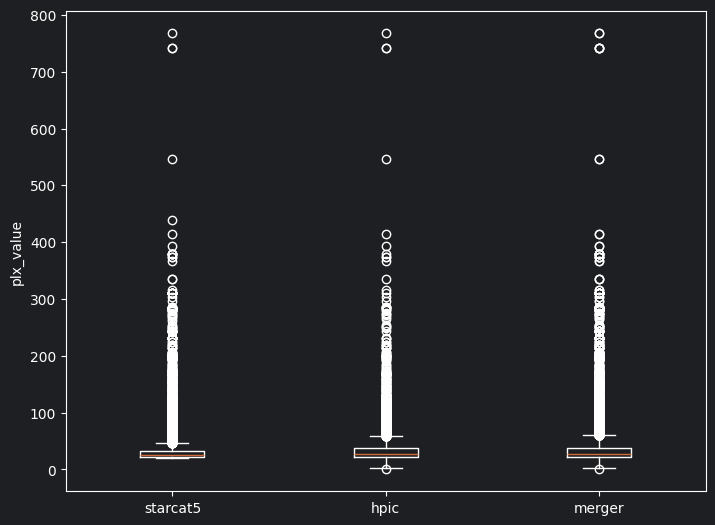

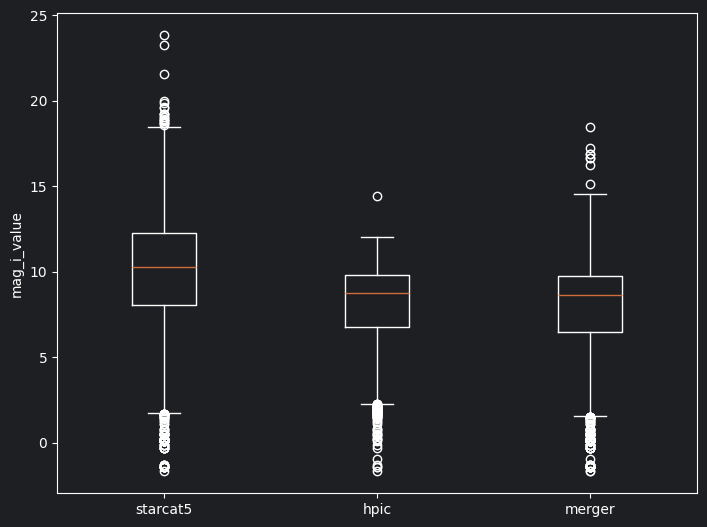

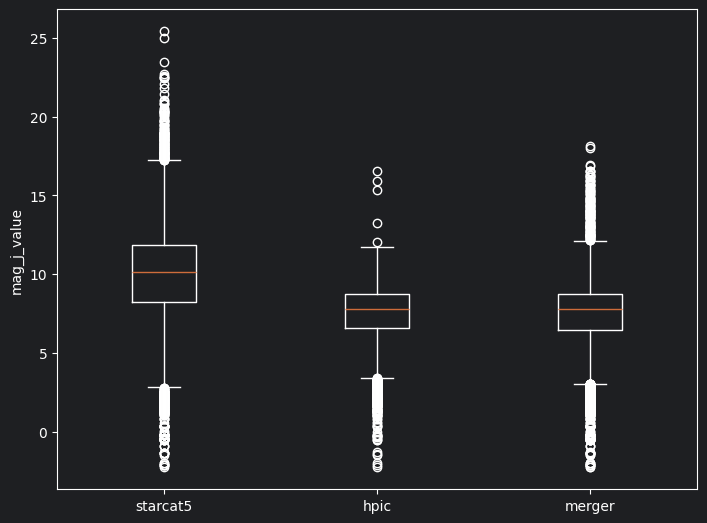

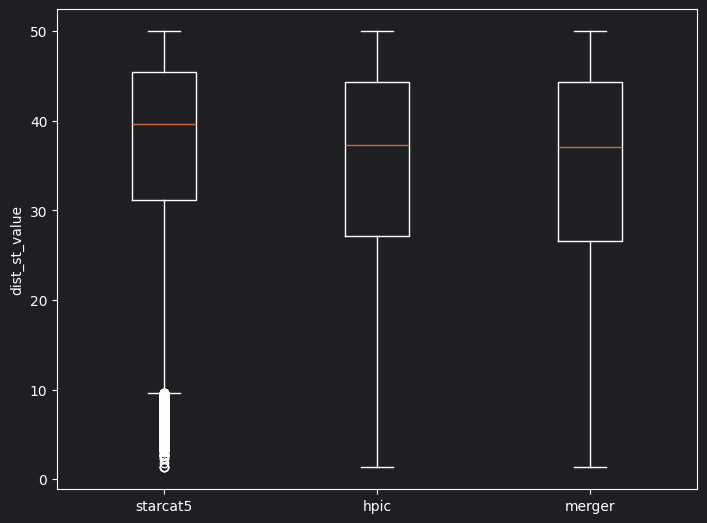

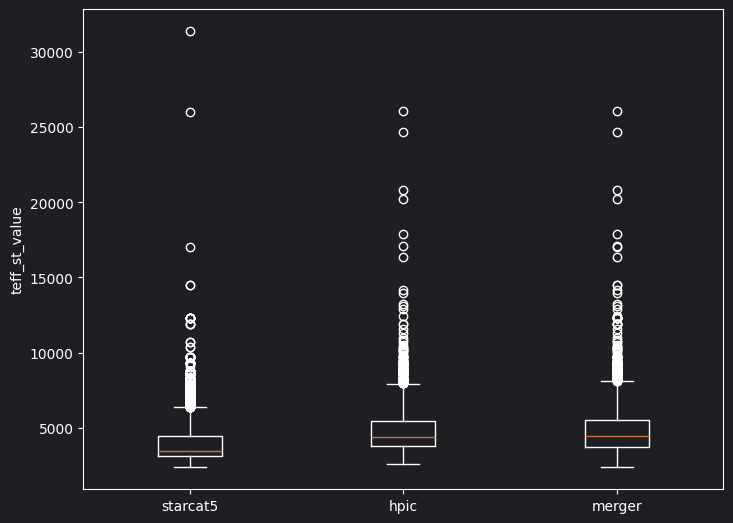

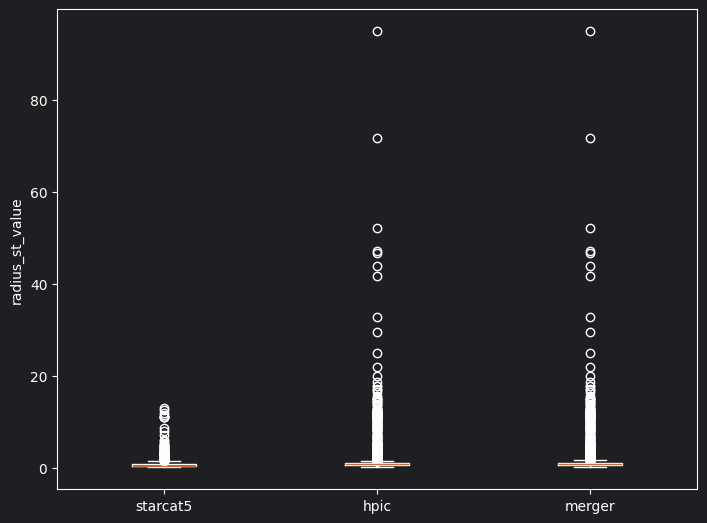

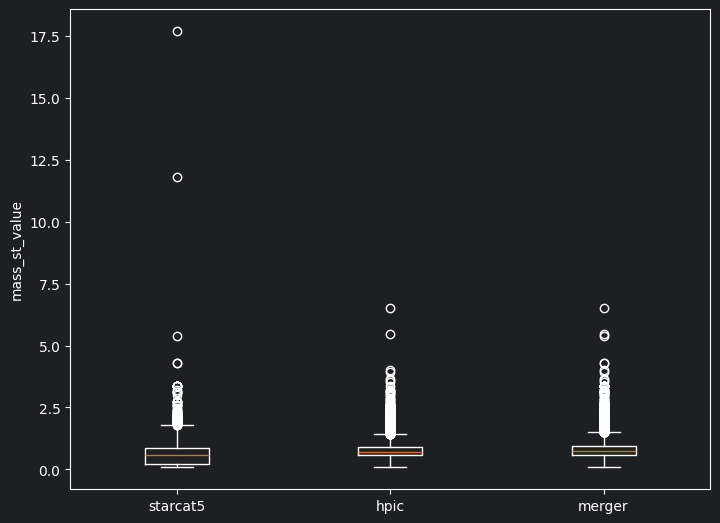

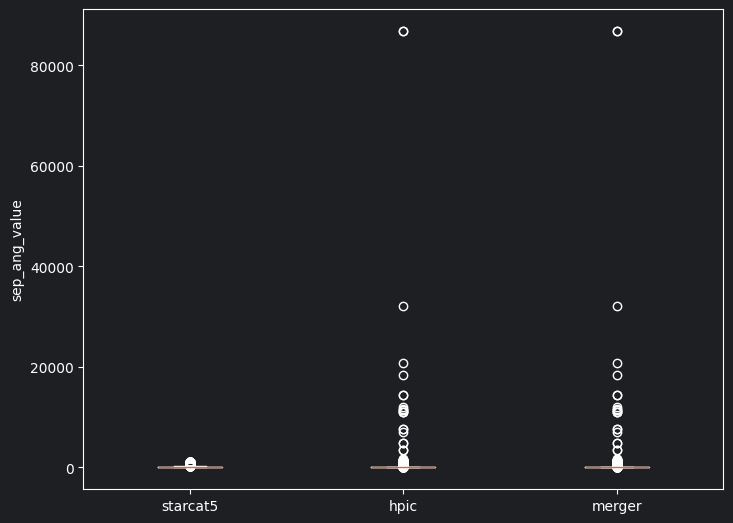

In [36]:
#dist,mass,rad,teff
for col in float_colnames:
    x = pre_merge_hpic_masked['temp_'+col]
    hpic_prepped = x[~np.isnan(x)]
    y = catalog['temp_'+col]
    catalog_prepped = y[~np.isnan(y)]
    catalog_versions.threecatboxplot([starcat5[col],
                                      hpic_prepped, catalog_prepped],
                                     col, ["starcat5", "hpic", "merger"])

# why are hpic and catalog not shown?
# because of masked elements? -> looks like it as when i only take first 10 elements it works
# does not seem to be the case because first column is not a masked one
# or is it because the amount of objects is different?
# ... its the nans that are inside. hm how do I remove it? did not work with np.where and != np.nan
# try x = x[~numpy.isnan(x)] -> worked!


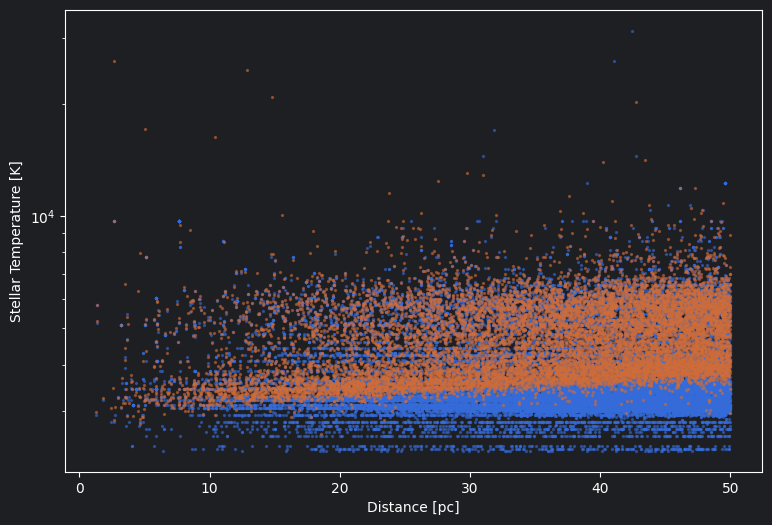

In [22]:

ylabel = "Stellar Temperature [K]"

fig, ax = plt.subplots(
        figsize=(9, 6)
    )  # subplots so that I can overplot old version?

ax.scatter(starcat5["dist_st_value"], starcat5["teff_st_value"], s=2, alpha=0.5)
ax.scatter(pre_merge_hpic_masked["temp_dist_st_value"], pre_merge_hpic_masked["temp_teff_st_value"], s=2, alpha=0.5)
ax.set_yscale("log")

ax.set_xlabel("Distance [pc]")
ax.set_ylabel(ylabel)
plt.show()

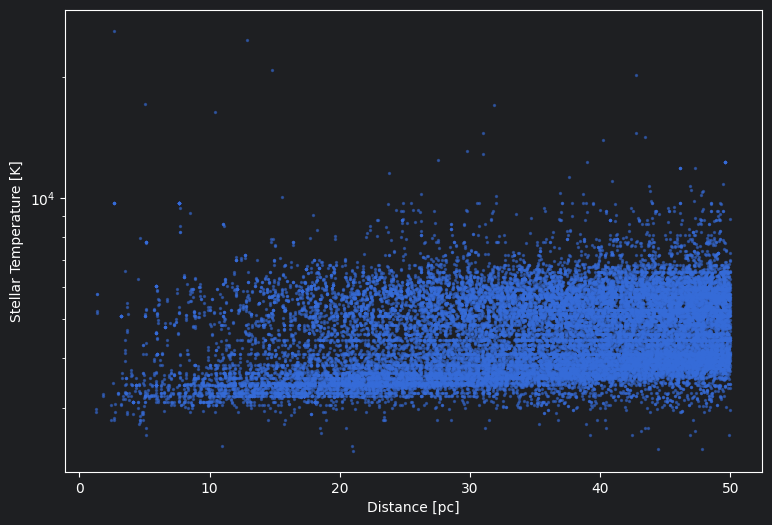

In [23]:

ylabel = "Stellar Temperature [K]"

fig, ax = plt.subplots(
    figsize=(9, 6)
)  # subplots so that I can overplot old version?

ax.scatter(catalog["temp_dist_st_value"],
           catalog["temp_teff_st_value"], s=2, alpha=0.5)
ax.set_yscale("log")

ax.set_xlabel("Distance [pc]")
ax.set_ylabel(ylabel)
plt.show()


## Input
try to query different archives outside of db context

In [3]:
from provider.utils import query

### Gaia

Notes: I could technically structurize it more (input parameters, output parameters,...) but don't think is useful at this point as not all sources will be via adql. better get list first, then write function for structuring.

In [1]:
adql_query = """
    SELECT s.source_id ,p.mass_flame, p.radius_flame,
        p.teff_gspphot, p.teff_gspspec, m.nss_solution_type, p.age_flame,
        p.teff_gspspec_lower, p.teff_gspspec_upper, p.flags_gspspec
    FROM gaiadr3.gaia_source as s
        JOIN gaiadr3.astrophysical_parameters as p ON s.source_id=p.source_id
            LEFT JOIN gaiadr3.nss_two_body_orbit as m ON s.source_id=m.source_id
    WHERE s.parallax >=30."""

gaia_helptab = query("https://gea.esac.esa.int/tap-server/tap", adql_query)

Service is UP and running.


In [2]:
print(gaia_helptab)

     source_id      mass_flame ...               flags_gspspec              
                     solMass   ...                                          
------------------- ---------- ... -----------------------------------------
    769456276704128         -- ...                                          
  56252256123908096         -- ...                                          
  60186343087140096  0.7181468 ... 00000000000001110009900001000999999999995
  73326018139806592         -- ... 00100111000009999999999999999999999999999
  78649033103283584         -- ...                                          
  98092934167683072         -- ...                                          
 115311458058061440  0.8797081 ... 00000000000001010000000109900990099999995
 115851902384016128         -- ...                                          
 126342377182577408         -- ...                                          
                ...        ... ...                                       ...

### HWO

In [ ]:
# spores see utils.analysis.create_other_catalogs
# same for HPIC
# so far both accessed via downloaded csv file. as they are not supposed to change often, I could keep it that way
# spores can be downloaded at https://sites.google.com/berkeley.edu/spores-hwo/science
# old saving location is Nebenproject/life_cat/data

## Reformatting

In [ ]:
# input table
# changes in column name
# changes in data e.g. unit


## Saving

In [ ]:
# input table (astropy? or pandas)
# output structure, so far

save(
    [table],
    ["name"],
    location="...",
)